Authors: Raphael Balzer, Kevin Paulus

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("Train_Test_datasets/Train_Test_Network_dataset/train_test_network.csv")
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
df_train.head()

,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
71453,192.168.1.31,50206,18.184.104.180,80,tcp,http,1.339110,287,12183,SF,...,0,0,-,-,-,-,-,-,1,injection
205318,192.168.1.32,53412,52.28.231.150,80,tcp,-,0.000000,0,0,S0,...,0,0,-,-,-,-,-,-,1,xss
126310,192.168.1.193,80,192.168.1.193,1615,tcp,-,0.247252,0,0,S0,...,0,0,-,-,-,-,-,-,0,normal
162393,192.168.1.193,49245,192.168.1.33,4444,tcp,-,0.000000,0,0,OTH,...,0,0,-,-,-,-,-,-,1,ransomware
178827,192.168.1.30,50575,192.168.1.49,1040,tcp,-,0.000000,0,0,S0,...,0,0,-,-,-,-,-,-,1,scanning


In [111]:

import numpy as np
df_train['mean_bytes_dst'] = df_train['dst_bytes'] / (df_train['dst_pkts'] + 1) # mittel bis schwach
df_train['ratio_bytes'] = df_train['src_bytes'] / (df_train['dst_bytes'] + 1) # mittel bis schwach
df_train['dst_pkts_per_sec'] = df_train['dst_pkts'] / (df_train['duration'] + 1e-3) # stark
df_train['velocity_bytes'] = (df_train['src_bytes'] + df_train['dst_bytes']) / (df_train['duration'] + 1e-3) # schwach
df_train['velocity_pkts'] = (df_train['src_pkts'] + df_train['dst_pkts']) / (df_train['duration'] + 1e-3)
df_train['dns_bytes_fraction'] = df_train['dst_bytes'] / (df_train['src_bytes'] + df_train['dst_bytes'] + 1) # stark
df_train['has_dns'] = ~df_train['dns_query'].isnull() # stark
df_train['dns_pkts_ratio'] = df_train['has_dns'] * (df_train['dst_pkts'] / (df_train['src_pkts'] + 1)) # stark
df_train['mean_bytes_src'] = df_train['src_bytes'] / (df_train['src_pkts'] + 1) # mittel
df_train['ratio_pkts'] = df_train['src_pkts'] / (df_train['dst_pkts'] + 1) # stark
df_train['dst_bytes_per_sec'] = df_train['dst_bytes'] / (df_train['duration'] + 1e-3) # schwach
df_train['mean_bytes_dst'] = df_train['dst_bytes'] / (df_train['dst_pkts'] + 1) # schwach
dns_mask = df_train['has_dns'] == 1

for col in ['dst_pkts_per_sec', 'dns_pkts_ratio']: # mittel eher weglassen
    med = df_train.loc[dns_mask, col].median()
    iqr = (
        df_train.loc[dns_mask, col].quantile(0.75)
        - df_train.loc[dns_mask, col].quantile(0.25)
    )
    df_train[f'{col}_dns_z'] = df_train['has_dns'] * ((df_train[col] - med) / (iqr + 1e-3))

df_train['pkt_payload_mismatch'] = ( #mittel bis stark
    df_train['dst_pkts_per_sec'] /
    (df_train['mean_bytes_dst'] + 1)
)
df_train['missed_bytes_ratio'] = df_train['missed_bytes'] / (df_train['src_bytes'] + df_train['dst_bytes'] + 1) # keine separation
#df_train['scan_intensity'] = df_train['conn_state_S0'] * df_train['src_pkts']
df_train['bidirectional_ratio'] = ( # stark
    df_train['dst_pkts'] * df_train['src_pkts'] /
    ((df_train['dst_pkts'] + df_train['src_pkts']) ** 2 + 1)
)
df_train['is_burst'] = ( # stark
    (df_train['velocity_bytes'] > df_train['velocity_bytes'].quantile(0.9)) &
    (df_train['duration'] < df_train['duration'].quantile(0.5))
).astype(int)
df_train['unidirectional_bytes'] = ( #stark
    ((df_train['src_bytes'] == 0) | (df_train['dst_bytes'] == 0)) &
    ((df_train['src_bytes'] + df_train['dst_bytes']) > 0)
).astype(int)
freq_map = df_train["conn_state"].value_counts(normalize=True).to_dict()
df_train['conn_state_freq'] = df_train["conn_state"].map(freq_map)

ANALYSE: dns_heavy_flow

Klassenverteilung:
label
1    128834
0     40000
Name: count, dtype: int64
label
1    0.763081
0    0.236919
Name: proportion, dtype: float64

Anzahl unique values: 2
Datentyp: int64

>>> BINÄRES FEATURE <<<

--- Kontingenz-Tabelle (Absolute Zahlen) ---
label               0       1     All
dns_heavy_flow                       
0               39248  122337  161585
1                 752    6497    7249
All             40000  128834  168834

--- Kontingenz-Tabelle (% pro Label) ---
label               0      1
dns_heavy_flow              
0               98.12  94.96
1                1.88   5.04

--- Chi-Quadrat Test ---
Chi2: 742.3328
p-value: 0.000000
Signifikant unterschiedlich: ✅ JA

--- Malicious Rate (%) pro Kategorie ---
dns_heavy_flow
0    75.71
1    89.63
Name: label, dtype: float64


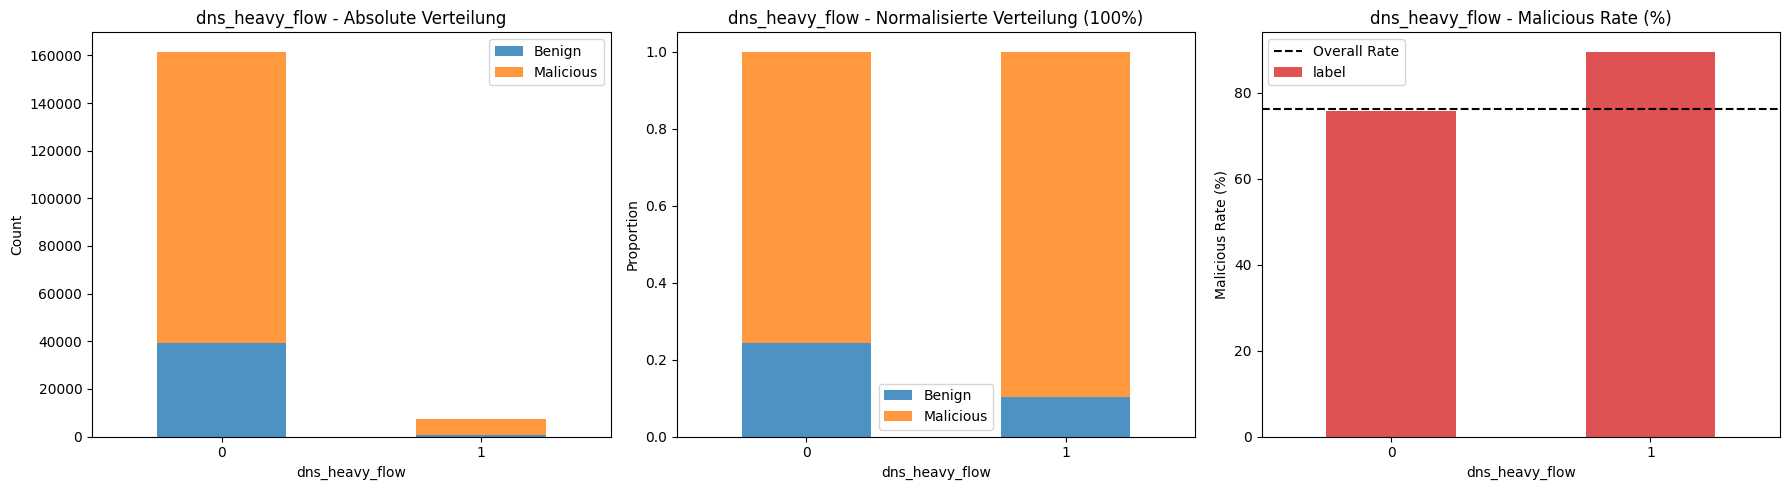

In [110]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

def analyze_categorical_feature(df, column, label_col='label', top_n=15):
    """
    Analysiert die Trennschärfe eines kategorischen oder binären Features.
    
    Parameters:
    -----------
    df : DataFrame
    column : str - Name des zu analysierenden Features
    label_col : str - Name der Label-Spalte
    top_n : int - Anzahl der häufigsten Kategorien (für kategorische Features)
    """
    
    print("="*80)
    print(f"ANALYSE: {column}")
    print("="*80)
    
    # Klassenverteilung
    print("\nKlassenverteilung:")
    print(df[label_col].value_counts())
    print(df[label_col].value_counts(normalize=True))
    
    # Unique values und Datentyp
    n_unique = df[column].nunique()
    print(f"\nAnzahl unique values: {n_unique}")
    print(f"Datentyp: {df[column].dtype}")
    
    # Bestimme ob binär oder kategorisch
    is_binary = n_unique == 2
    
    if is_binary:
        print(f"\n>>> BINÄRES FEATURE <<<")
        _analyze_binary_feature(df, column, label_col)
    else:
        print(f"\n>>> KATEGORISCHES FEATURE (Top {top_n} Kategorien) <<<")
        _analyze_categorical_feature(df, column, label_col, top_n)
    
    print("\n" + "="*80 + "\n")


def _analyze_binary_feature(df, column, label_col='label'):
    """Analysiert binäre Features (0/1 oder True/False)"""
    
    # Kontingenz-Tabelle
    contingency = pd.crosstab(df[column], df[label_col], margins=True, normalize=False)
    print("\n--- Kontingenz-Tabelle (Absolute Zahlen) ---")
    print(contingency)
    
    # Normalisierte Version (Prozent pro Label)
    contingency_norm = pd.crosstab(df[column], df[label_col], normalize='columns') * 100
    print("\n--- Kontingenz-Tabelle (% pro Label) ---")
    print(contingency_norm.round(2))
    
    # Chi-Quadrat Test
    chi2, p_value, dof, expected = chi2_contingency(
        pd.crosstab(df[column], df[label_col])
    )
    print(f"\n--- Chi-Quadrat Test ---")
    print(f"Chi2: {chi2:.4f}")
    print(f"p-value: {p_value:.6f}")
    print(f"Signifikant unterschiedlich: {'✅ JA' if p_value < 0.001 else '❌ NEIN'}")
    
    # Malicious Rate pro Kategorie
    malicious_rate = df.groupby(column)[label_col].mean() * 100
    print(f"\n--- Malicious Rate (%) pro Kategorie ---")
    print(malicious_rate.round(2))
    
    # Visualisierung
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Stacked Bar Chart (Absolute Zahlen)
    contingency_plot = pd.crosstab(df[column], df[label_col])
    contingency_plot.plot(kind='bar', stacked=True, ax=axes[0], 
                          color=['#1f77b4', '#ff7f0e'], alpha=0.8)
    axes[0].set_title(f'{column} - Absolute Verteilung')
    axes[0].set_xlabel(column)
    axes[0].set_ylabel('Count')
    axes[0].legend(['Benign', 'Malicious'])
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
    
    # 2. Normalized Stacked Bar (100%)
    contingency_norm_plot = pd.crosstab(df[column], df[label_col], normalize='index')
    contingency_norm_plot.plot(kind='bar', stacked=True, ax=axes[1],
                               color=['#1f77b4', '#ff7f0e'], alpha=0.8)
    axes[1].set_title(f'{column} - Normalisierte Verteilung (100%)')
    axes[1].set_xlabel(column)
    axes[1].set_ylabel('Proportion')
    axes[1].legend(['Benign', 'Malicious'])
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
    
    # 3. Malicious Rate
    malicious_rate.plot(kind='bar', ax=axes[2], color='#d62728', alpha=0.8)
    axes[2].set_title(f'{column} - Malicious Rate (%)')
    axes[2].set_xlabel(column)
    axes[2].set_ylabel('Malicious Rate (%)')
    axes[2].axhline(df[label_col].mean() * 100, color='black', 
                    linestyle='--', label='Overall Rate')
    axes[2].legend()
    axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)
    
    plt.tight_layout()
    plt.show()


def _analyze_categorical_feature(df, column, label_col='label', top_n=15):
    """Analysiert kategorische Features mit vielen Werten"""
    
    # Top-N häufigste Kategorien
    top_categories = df[column].value_counts().head(top_n).index.tolist()
    df_filtered = df[df[column].isin(top_categories)].copy()
    
    print(f"\nAnalyse der Top {top_n} häufigsten Kategorien:")
    print(f"Abgedeckte Samples: {len(df_filtered)} / {len(df)} ({len(df_filtered)/len(df)*100:.1f}%)")
    
    # Kontingenz-Tabelle
    contingency = pd.crosstab(df_filtered[column], df_filtered[label_col], margins=True)
    print("\n--- Kontingenz-Tabelle (Top Categories) ---")
    print(contingency.sort_values('All', ascending=False))
    
    # Chi-Quadrat Test
    chi2, p_value, dof, expected = chi2_contingency(
        pd.crosstab(df_filtered[column], df_filtered[label_col])
    )
    print(f"\n--- Chi-Quadrat Test ---")
    print(f"Chi2: {chi2:.4f}")
    print(f"p-value: {p_value:.6f}")
    print(f"Signifikant unterschiedlich: {'✅ JA' if p_value < 0.001 else '❌ NEIN'}")
    
    # Malicious Rate pro Kategorie (sortiert)
    malicious_rate = df_filtered.groupby(column)[label_col].mean() * 100
    malicious_rate_sorted = malicious_rate.sort_values(ascending=False)
    print(f"\n--- Malicious Rate (%) pro Kategorie (sortiert) ---")
    print(malicious_rate_sorted.round(2))
    
    # Visualisierung
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # 1. Frequency Distribution
    value_counts = df_filtered[column].value_counts().sort_values(ascending=False)
    value_counts.plot(kind='bar', ax=axes[0, 0], color='steelblue', alpha=0.8)
    axes[0, 0].set_title(f'{column} - Häufigkeitsverteilung (Top {top_n})')
    axes[0, 0].set_xlabel(column)
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # 2. Malicious Rate (sortiert)
    malicious_rate_sorted.plot(kind='barh', ax=axes[0, 1], color='#d62728', alpha=0.8)
    axes[0, 1].set_title(f'{column} - Malicious Rate (%) - Sortiert')
    axes[0, 1].set_xlabel('Malicious Rate (%)')
    axes[0, 1].axvline(df[label_col].mean() * 100, color='black', 
                       linestyle='--', label='Overall Rate')
    axes[0, 1].legend()
    
    # 3. Stacked Bar Chart (Absolute)
    contingency_plot = pd.crosstab(df_filtered[column], df_filtered[label_col])
    contingency_plot = contingency_plot.loc[value_counts.index]  # Sort by frequency
    contingency_plot.plot(kind='bar', stacked=True, ax=axes[1, 0],
                         color=['#1f77b4', '#ff7f0e'], alpha=0.8)
    axes[1, 0].set_title(f'{column} - Absolute Verteilung')
    axes[1, 0].set_xlabel(column)
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].legend(['Benign', 'Malicious'])
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # 4. Normalized Stacked Bar (100%)
    contingency_norm = pd.crosstab(df_filtered[column], df_filtered[label_col], 
                                   normalize='index')
    contingency_norm = contingency_norm.loc[value_counts.index]
    contingency_norm.plot(kind='bar', stacked=True, ax=axes[1, 1],
                         color=['#1f77b4', '#ff7f0e'], alpha=0.8)
    axes[1, 1].set_title(f'{column} - Normalisierte Verteilung (100%)')
    axes[1, 1].set_xlabel(column)
    axes[1, 1].set_ylabel('Proportion')
    axes[1, 1].legend(['Benign', 'Malicious'])
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()


# ============================================================================
# VERWENDUNGSBEISPIELE
# ============================================================================

# Beispiel 1: Binäres Feature
analyze_categorical_feature(df_train, 'dns_heavy_flow')
# analyze_categorical_feature(df_train, 'is_incomplete_connection')
# analyze_categorical_feature(df_train, 'zero_payload_connection')

# Beispiel 2: Kategorisches Feature
#analyze_categorical_feature(df_train, 'duration_bin', top_n=5)
# analyze_categorical_feature(df_train, 'service', top_n=15)
# analyze_categorical_feature(df_train, 'conn_state', top_n=20)


       conn_state_freq
label                 
0             0.203621
1             0.175385

Klassenverteilung:
label
1    128834
0     40000
Name: count, dtype: int64
label
1    0.763081
0    0.236919
Name: proportion, dtype: float64


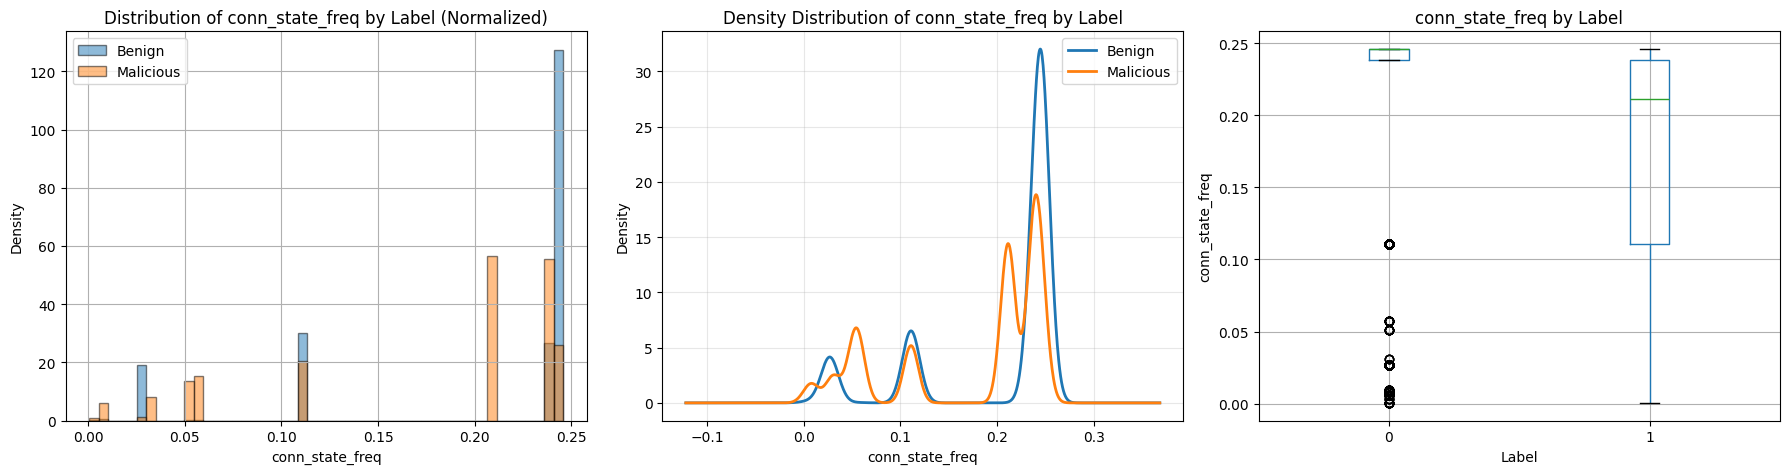

In [112]:
import matplotlib.pyplot as plt
import numpy as np
column = 'conn_state_freq'
# 1. Mittelwerte anzeigen (bereits im Code, ist gut)
print(df_train[[column, 'label']].groupby('label').mean())

# Klassenverteilung prüfen
print("\nKlassenverteilung:")
print(df_train['label'].value_counts())
print(df_train['label'].value_counts(normalize=True))

# Kombinierte Figure mit 3 Subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 2. NORMALISIERTE Histogramme (empfohlen!)
df_train[df_train['label'] == 0][column].hist(
    alpha=0.5, bins=50, label='Benign', density=True, edgecolor='black', ax=axes[0]
)
df_train[df_train['label'] == 1][column].hist(
    alpha=0.5, bins=50, label='Malicious', density=True, edgecolor='black', ax=axes[0]
)
axes[0].legend()
axes[0].set_title(f'Distribution of {column} by Label (Normalized)')
axes[0].set_xlabel(column)
axes[0].set_ylabel('Density')

# 3. Alternative: KDE Plot (oft besser lesbar)
df_train[df_train['label'] == 0][column].plot.kde(label='Benign', linewidth=2, ax=axes[1])
df_train[df_train['label'] == 1][column].plot.kde(label='Malicious', linewidth=2, ax=axes[1])
axes[1].legend()
axes[1].set_title(f'Density Distribution of {column} by Label')
axes[1].set_xlabel(column)
axes[1].set_ylabel('Density')
axes[1].grid(alpha=0.3)

# 4. Alternative: Boxplots für direkten Vergleich
df_train.boxplot(column=column, by='label', ax=axes[2])
axes[2].set_title(f'{column} by Label')
axes[2].set_xlabel('Label')
axes[2].set_ylabel(column)

plt.suptitle('')
plt.tight_layout()
plt.show()

Statistiken für conn_state_freq:
          count      mean       std       min       25%       50%       75%  \
label                                                                         
0       40000.0  0.203621  0.074879  0.000557  0.238429  0.245863  0.245863   
1      128834.0  0.175385  0.080813  0.000557  0.110991  0.211444  0.238429   

            max  
label            
0      0.245863  
1      0.245863  

Percentile für Label=0:
0.500    0.245863
0.900    0.245863
0.950    0.245863
0.990    0.245863
0.999    0.245863
Name: conn_state_freq, dtype: float64

Percentile für Label=1:
0.500    0.211444
0.900    0.245863
0.950    0.245863
0.990    0.245863
0.999    0.245863
Name: conn_state_freq, dtype: float64


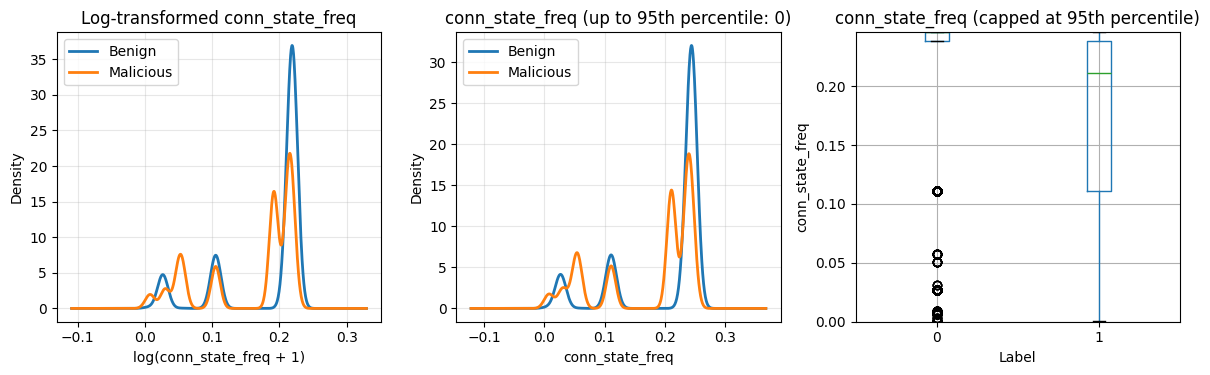


=== Ausreißer-Analyse ===

Anzahl Ausreißer (>99th percentile):
Series([], Name: count, dtype: int64)

Anteil Ausreißer pro Klasse:
label
0   NaN
1   NaN
Name: count, dtype: float64


In [113]:
import matplotlib.pyplot as plt
import numpy as np
column = 'conn_state_freq'
# 1. Erst die Verteilung der Werte verstehen
print(f"Statistiken für {column}:")
print(df_train.groupby('label')[column].describe())

print("\nPercentile für Label=0:")
print(df_train[df_train['label']==0][column].quantile([0.5, 0.9, 0.95, 0.99, 0.999]))

print("\nPercentile für Label=1:")
print(df_train[df_train['label']==1][column].quantile([0.5, 0.9, 0.95, 0.99, 0.999]))

# 2. Log-Transformation für bessere Visualisierung
df_train[f'{column}_log'] = np.log1p(df_train[column])

plt.figure(figsize=(12, 4))

# Plot 1: Log-transformierte Werte
plt.subplot(1, 3, 1)
df_train[df_train['label'] == 0][f'{column}_log'].plot.kde(label='Benign', linewidth=2)
df_train[df_train['label'] == 1][f'{column}_log'].plot.kde(label='Malicious', linewidth=2)
plt.xlabel(f'log({column} + 1)')
plt.ylabel('Density')
plt.title(f'Log-transformed {column}')
plt.legend()
plt.grid(alpha=0.3)

# Plot 2: Nur Werte bis zum 95. Percentil (Ausreißer entfernen)
plt.subplot(1, 3, 2)
p95 = df_train[column].quantile(0.95)
df_filtered = df_train[df_train[column] <= p95]

df_filtered[df_filtered['label'] == 0][column].plot.kde(label='Benign', linewidth=2)
df_filtered[df_filtered['label'] == 1][column].plot.kde(label='Malicious', linewidth=2)
plt.xlabel(column)
plt.ylabel('Density')
plt.title(f'{column} (up to 95th percentile: {p95:.0f})')
plt.legend()
plt.grid(alpha=0.3)

# Plot 3: Boxplot mit y-Achsen-Limit
plt.subplot(1, 3, 3)
df_train.boxplot(column=column, by='label', ax=plt.gca())
plt.ylim(0, p95)  # Limit auf 95. Percentil
plt.suptitle('')
plt.title(f'{column} (capped at 95th percentile)')
plt.xlabel('Label')
plt.ylabel(column)

plt.tight_layout()
plt.show()

# 3. Alternative: Separate Analyse der Ausreißer
print("\n=== Ausreißer-Analyse ===")
threshold = df_train[column].quantile(0.99)
outliers = df_train[df_train[column] > threshold]
print(f"\nAnzahl Ausreißer (>99th percentile):")
print(outliers['label'].value_counts())
print(f"\nAnteil Ausreißer pro Klasse:")
print(outliers['label'].value_counts() / df_train['label'].value_counts())

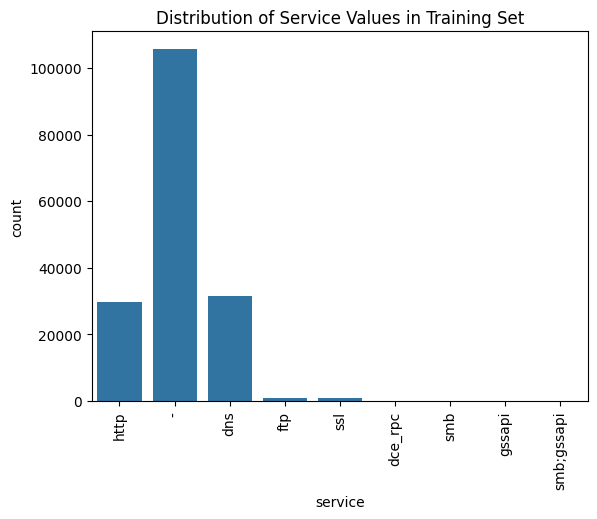

In [22]:
# plotting value distribution for service
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df_train, x='service')
plt.title('Distribution of Service Values in Training Set')
plt.xticks(rotation=90)
plt.show()

In [2]:
# printing all unique value counts for dns_query column
dns_query_counts = df_train['dns_query'].value_counts()
print(dns_query_counts)

dns_query
-                                                  141052
a2z3kk2ebqzso7.iot.ap-southeast-2.amazonaws.com      9005
testphp.vulnweb.com                                  1476
elasticsearch                                        1399
elasticsearch.mydns.com                              1381
                                                    ...  
107.35.168.192.in-addr.arpa                             1
ip6.arpa                                                1
eb2.3lift.com                                           1
onenote.net                                             1
e1.emxdgt.com                                           1
Name: count, Length: 693, dtype: int64


In [3]:
# Analyze http_uri values and their association with labels
import pandas as pd

# Create a cross-tabulation showing counts for each http_uri and label combination
http_uri_counts = df_train.groupby(['http_user_agent', 'label']).size().unstack(fill_value=0)

# Add columns for analysis
http_uri_counts['Total'] = http_uri_counts[0] + http_uri_counts[1]
http_uri_counts['Malicious_Rate'] = (http_uri_counts[1] / http_uri_counts['Total'] * 100).round(2)
http_uri_counts['Benign_Rate'] = (http_uri_counts[0] / http_uri_counts['Total'] * 100).round(2)

# Sort by total occurrences to see most common URIs
http_uri_counts_sorted = http_uri_counts.sort_values('Total', ascending=False)

print("=== DNS Query Analysis ===")
print(f"\nTotal unique DNS Queries: {len(http_uri_counts)}")
print("\n--- Top 20 Most Common DNS Queries ---")
print(http_uri_counts_sorted.head(20))


=== DNS Query Analysis ===

Total unique DNS Queries: 30

--- Top 20 Most Common DNS Queries ---
label                                                   0       1   Total  \
http_user_agent                                                             
-                                                   39803  128790  168593   
Microsoft-Delivery-Optimization/10.0                   57       0      57   
Microsoft-Windows/10.0 UPnP/1.0                        40       0      40   
Ruby                                                    0      27      27   
User-Agent: Microsoft-DLNA DLNADOC/1.50                20       0      20   
DAFUPnP                                                20       0      20   
Windows-Update-Agent/10.0.10011.16384 Client-Pr...     14       0      14   
Microsoft-Windows/10.0 UPnP/1.0 Microsoft-DLNA ...     11       0      11   
Microsoft NCSI                                          9       0       9   
MICROSOFT_DEVICE_METADATA_RETRIEVAL_CLIENT              

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211043 entries, 0 to 211042
Data columns (total 44 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   src_ip                  211043 non-null  object 
 1   src_port                211043 non-null  int64  
 2   dst_ip                  211043 non-null  object 
 3   dst_port                211043 non-null  int64  
 4   proto                   211043 non-null  object 
 5   service                 211043 non-null  object 
 6   duration                211043 non-null  float64
 7   src_bytes               211043 non-null  int64  
 8   dst_bytes               211043 non-null  int64  
 9   conn_state              211043 non-null  object 
 10  missed_bytes            211043 non-null  int64  
 11  src_pkts                211043 non-null  int64  
 12  src_ip_bytes            211043 non-null  int64  
 13  dst_pkts                211043 non-null  int64  
 14  dst_ip_bytes        

In [5]:
# checking the value counts for label
label_counts = df_train['label'].value_counts(normalize=True)
print("Label Distribution in Training Set:")
print(label_counts)

Label Distribution in Training Set:
label
1    0.763081
0    0.236919
Name: proportion, dtype: float64


## Phase 1: Struktur & "Null-Pattern" Analyse
Da wir hier verschiedene Protokolle in einer Tabelle haben, ist die Analyse der fehlenden Werte (Nulls) der wichtigste erste Schritt.

In [ ]:
#vizualizing missing values ("-" indicates missing values)
import matplotlib.pyplot as plt
import seaborn as sns
#converting "-" to NaN for better visualization
df_train.replace('-', pd.NA, inplace=True)

# Konvertiere DNS-numerische 0-Werte zu NA, wenn alle nicht-numerischen DNS-Spalten NA sind
dns_cols = [col for col in df_train.columns if col.startswith('dns')]
dns_numeric = [col for col in dns_cols if df_train[col].dtype in ['int64', 'float64']]
dns_non_numeric = [col for col in dns_cols if df_train[col].dtype not in ['int64', 'float64']]

if dns_non_numeric:
    # Maske: Zeilen wo ALLE nicht-numerischen DNS-Spalten NA sind
        all_non_numeric_na = df_train[dns_non_numeric].isnull().all(axis=1)
            
                # Setze numerische DNS-Spalten mit Wert 0 auf NA, wo Maske True ist
                    for col in dns_numeric:
                            df_train.loc[all_non_numeric_na & (df_train[col] == 0), col] = pd.NA

                            plt.figure(figsize=(12,8))
                            sns.heatmap(df_train.isnull(), cbar=False, cmap='viridis')
                            plt.title('Missing Values Heatmap')
                            plt.show()

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_na_association(df, columns):
    # Liste der Spalten mit vielen NaNs (basierend auf deiner Analyse)
    na_columns = columns
    # Nur Spalten nehmen, die auch im DF existieren
    na_columns = [col for col in na_columns if col in df.columns]
    
    # 1. Erstelle eine binäre Matrix: True wenn NaN, False wenn Wert da
    na_matrix = df[na_columns].isna()
    na_matrix['label'] = df['label']
    
    # 2. Berechne die relative Häufigkeit von NaNs PRO KLASSE
    # Damit wird die 70/30 Imbalance neutralisiert
    na_stats = []
    for col in na_columns:
        for label in [0, 1]:
            subset = na_matrix[na_matrix['label'] == label]
            na_rate = subset[col].mean() * 100 # Durchschnitt von True(1)/False(0) ist die Rate
            na_stats.append({
                'Feature': col,
                'Label': 'Normal (0)' if label == 0 else 'Angriff (1)',
                'NaN-Anteil [%]': na_rate
            })
    
    stats_df = pd.DataFrame(na_stats)
    
    # 3. Plotting
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")
    
    ax = sns.barplot(
        data=stats_df, 
        x='Feature', 
        y='NaN-Anteil [%]', 
        hue='Label', 
        palette={ 'Normal (0)': '#3498db', 'Angriff (1)': '#e74c3c' }
    )
    
    plt.title('Relative Häufigkeit von fehlenden Werten (NaN) pro Klasse\n(Normalisiert zur Neutralisierung der Klassen-Imbalance)', fontsize=14)
    plt.ylabel('Anteil der Datensätze mit NaNs [%]')
    plt.ylim(0, 105)
    
    # Prozentzahlen über die Balken schreiben
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontsize=10)

    plt.tight_layout()
    plt.show()

def get_col_group(starting_str, df):
    return [col for col in df.columns if col.startswith(starting_str)]

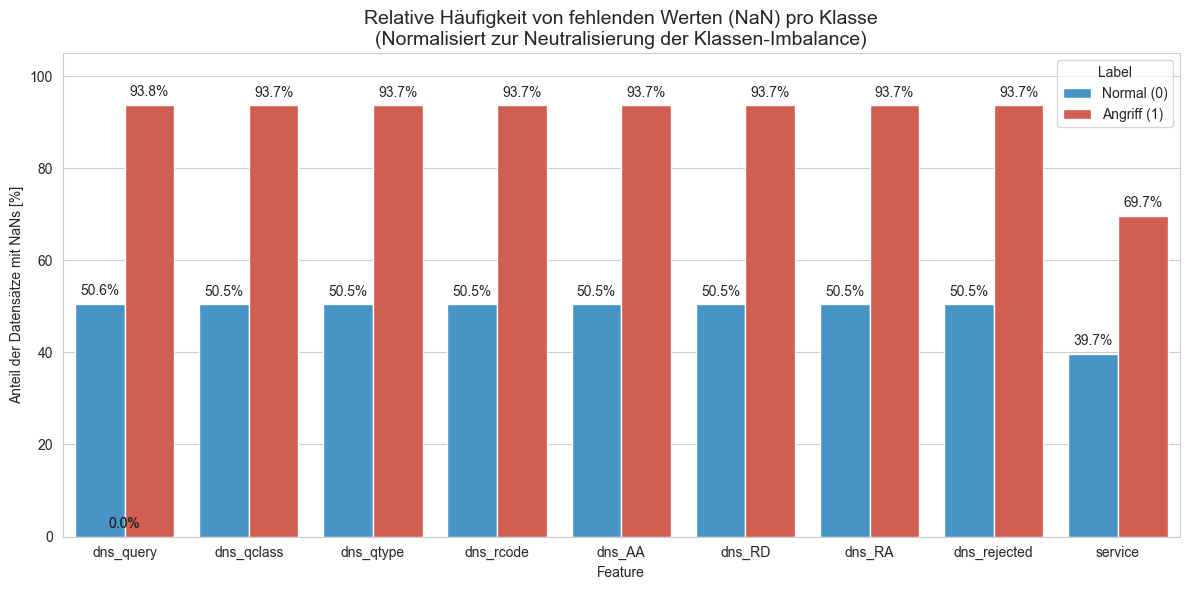

In [34]:
df_train.replace('-', pd.NA, inplace=True)
ssl_cols = get_col_group('ssl_', df_train)
http_cols = get_col_group('http_', df_train)
dns_cols = get_col_group('dns_', df_train)
weird_cols = get_col_group('weird_', df_train)
plot_na_association(df_train, columns=dns_cols+["service"])

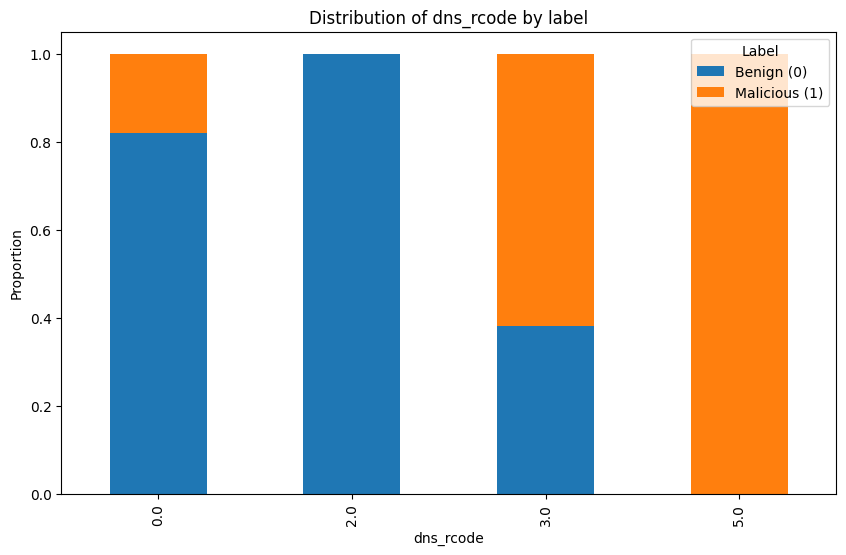

In [7]:
# checking distribution of dns_rcode with regard to label
dns_rcode_dist = pd.crosstab(df_train['dns_rcode'], df_train['label'], normalize='index')
dns_rcode_dist.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Distribution of dns_rcode by label')
plt.xlabel('dns_rcode')
plt.ylabel('Proportion')
plt.legend(title='Label', loc='upper right', labels=['Benign (0)', 'Malicious (1)'])
plt.show()

### Interpretation der Heatmap
#### 1. Der "Basis-Block" (Links - Lila):

- Spalten wie ``src_ip``, ``dst_port``, ``duration``, ``src_bytes`` sind durchgehend lila (vorhanden).

- Erkenntnis: Das sind die Basis-Flow-Daten (TCP/UDP Header). Jedes Paket hat diese Infos. Das ist das Fundament für Ihren "David" (Isolation Forest).

#### 2. Das Treppenstufen-Muster (Mitte/Rechts - Gelb/Lila Blöcke):

- Sie sehen klare Blöcke, die sich gegenseitig ausschließen.

- Der Block ``dns_...`` ist lila, wenn ``http_...`` gelb ist.

- Erkenntnis: Eine Verbindung ist entweder DNS oder HTTP oder SSL. Ein DNS-Request kann keinen http_user_agent haben.

- Wichtig: Diese NaNs sind keine Fehler. Sie bedeuten "Nicht anwendbar".

#### 3. Die "Service"-Lücken:

- Die Spalte service (ziemlich weit links) hat gelbe Streifen.

- Erkenntnis: Das sind Verbindungen, bei denen das IDS (Zeek) das Protokoll nicht erkennen konnte.

- Hypothese: Angriffe nutzen oft unbekannte oder verschleierte Protokolle. Wenn service fehlt (NaN), könnte die Wahrscheinlichkeit für label=1 höher sein.

#### 4. Die leere Wüste (Rechts):

- Die ``ssl_...`` und ``weird_...`` Spalten sind fast komplett gelb.

- Erkenntnis: SSL-Metadaten und "Weird"-Logs sind selten. Aber Vorsicht: Wenn weird_notice mal vorhanden ist (lila), ist das ein extrem starkes Signal für eine Anomalie!

### Schritt 1: Quantifizierung & Bereinigung
Zuerst müssen wir wissen: Welche Spalten sind zu 99,9% leer und können weg?

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Angenommen, dein DataFrame heißt 'df_train'
# df_train = pd.read_csv('dein_datenpfad.csv')

# 1. Berechne den Prozentsatz fehlender Werte pro Spalte
missing_percent = df_train.isnull().mean() * 100
missing_df_train = pd.DataFrame(missing_percent, columns=['% Missing']).sort_values('% Missing', ascending=False)

print("Top 10 Spalten mit den meisten fehlenden Werten:")
print(missing_df_train.head(10))

# Entscheidungshilfe: Alles über 99% wegwerfen?
# VORSICHT: 'weird_notice' könnte selten, aber wichtig sein.
# Wir markieren Spalten zum Droppen nur, wenn sie wirklich fast leer sind UND unwichtig erscheinen
cols_to_drop = missing_percent[missing_percent > 99.5].index.tolist()
print(f"\nKandidaten zum Löschen (>99.5% leer): {cols_to_drop}")

Top 10 Spalten mit den meisten fehlenden Werten:
                      % Missing
ssl_issuer            99.995854
ssl_subject           99.995854
http_orig_mime_types  99.991708
weird_addl            99.926555
http_resp_mime_types  99.902271
http_user_agent       99.857256
http_uri              99.857256
http_method           99.857256
http_version          99.853702
http_trans_depth      99.851333

Kandidaten zum Löschen (>99.5% leer): ['ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice']


### Schritt 2: Die "Service"-Hypothese testen
Ist ein fehlender service-Eintrag ein Indikator für einen Angriff?


Wahrscheinlichkeit eines Angriffs (Label 1), wenn 'service' fehlt:
label                      0         1
service_is_missing                    
False               0.381578  0.618422
True                0.150358  0.849642


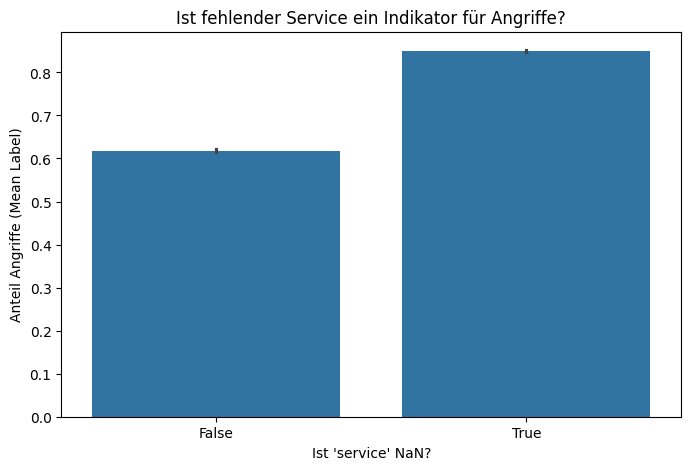

In [9]:
# Wir erstellen eine temporäre Spalte: Hat Service-Info oder nicht?
df_train['service_is_missing'] = df_train['service'].isnull()

# Kreuztabelle erstellen: Label vs. Missing Service
crosstab = pd.crosstab(df_train['service_is_missing'], df_train['label'], normalize='index')
print("\nWahrscheinlichkeit eines Angriffs (Label 1), wenn 'service' fehlt:")
print(crosstab)

# Visualisierung
plt.figure(figsize=(8, 5))
sns.barplot(x='service_is_missing', y='label', data=df_train)
plt.title("Ist fehlender Service ein Indikator für Angriffe?")
plt.ylabel("Anteil Angriffe (Mean Label)")
plt.xlabel("Ist 'service' NaN?")
plt.show()

In [10]:
# ausgabe der kardinalität für alle kategorischen spalten
categorical_cols = df_train.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    cardinality = df_train[col].nunique()
    print(f"Kardinalität der Spalte '{col}': {cardinality}")

Kardinalität der Spalte 'src_ip': 51
Kardinalität der Spalte 'dst_ip': 708
Kardinalität der Spalte 'proto': 3
Kardinalität der Spalte 'service': 8
Kardinalität der Spalte 'conn_state': 13
Kardinalität der Spalte 'dns_query': 692
Kardinalität der Spalte 'dns_AA': 2
Kardinalität der Spalte 'dns_RD': 2
Kardinalität der Spalte 'dns_RA': 2
Kardinalität der Spalte 'dns_rejected': 2
Kardinalität der Spalte 'ssl_version': 3
Kardinalität der Spalte 'ssl_cipher': 5
Kardinalität der Spalte 'ssl_resumed': 2
Kardinalität der Spalte 'ssl_established': 2
Kardinalität der Spalte 'ssl_subject': 4
Kardinalität der Spalte 'ssl_issuer': 3
Kardinalität der Spalte 'http_trans_depth': 9
Kardinalität der Spalte 'http_method': 3
Kardinalität der Spalte 'http_uri': 73
Kardinalität der Spalte 'http_version': 1
Kardinalität der Spalte 'http_user_agent': 29
Kardinalität der Spalte 'http_orig_mime_types': 2
Kardinalität der Spalte 'http_resp_mime_types': 9
Kardinalität der Spalte 'weird_name': 9
Kardinalität der Sp

### Schritt 3: Protokoll-Exklusivität prüfen
Wir überprüfen, ob sich DNS, HTTP und SSL wirklich ausschließen, um das "Treppenmuster" zu bestätigen.

In [11]:
# Wir zählen, wie viele Protokoll-spezifische Felder gleichzeitig gefüllt sind
# Wir nehmen jeweils einen Stellvertreter pro Protokoll
df_train['has_dns'] = ~df_train['dns_query'].isnull()
df_train['has_http'] = ~df_train['http_uri'].isnull()
df_train['has_ssl'] = ~df_train['ssl_cipher'].isnull()

# Überlappung prüfen
overlap = df_train[['has_dns', 'has_http', 'has_ssl']].sum(axis=1).value_counts()
print("\nAnzahl der Protokolle pro Verbindung (sollte meistens 0 oder 1 sein):")
print(overlap)
# Wenn hier viele 2er oder 3er sind, stimmt etwas nicht mit den Daten!


Anzahl der Protokolle pro Verbindung (sollte meistens 0 oder 1 sein):
0    140493
1     28341
Name: count, dtype: int64


### Interpretation der Ergebnisse
- Die "Dunkelziffer" ist riesig (Protokoll-Exklusivität):

- Das Ergebnis 0: 140513 bei der Protokoll-Zählung ist der wichtigste Fund. Das bedeutet, dass bei über 95% der Verbindungen weder DNS, noch HTTP, noch SSL-Details erkannt wurden.

- Konsequenz für "David": Das bestätigt die Hypothese für den Isolation Forest. Wir müssen uns auf die Basis-Features (duration, bytes, ports, pkts) verlassen, da die detaillierten Protokoll-Informationen für die Masse der Daten schlicht nicht existieren.

### "Missing Service" ist ein Top-Feature:

- Die Wahrscheinlichkeit eines Angriffs springt von 61% auf 85%, wenn der service fehlt (NaN).

- Insight: Angreifer nutzen oft untypische Ports oder Protokolle, die der Zeek-Scanner nicht klassifizieren kann (z.B. ein Custom-C2-Protokoll über UDP). Das NaN in dieser Spalte ist also kein "Fehlen von Information", sondern eine Information an sich ("Unbekanntes Protokoll").

--- Analyse der Verbindungen ohne L7-Details ---
Anzahl Unbekannte: 140493
Verteilung Label (Angriff vs. Normal) bei Unbekannten:
label
1    0.859687
0    0.140313
Name: proportion, dtype: float64


C:\Users\rapha\AppData\Local\Temp\ipykernel_26512\1320123756.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_ports.index, y=top_ports.values, palette="viridis")


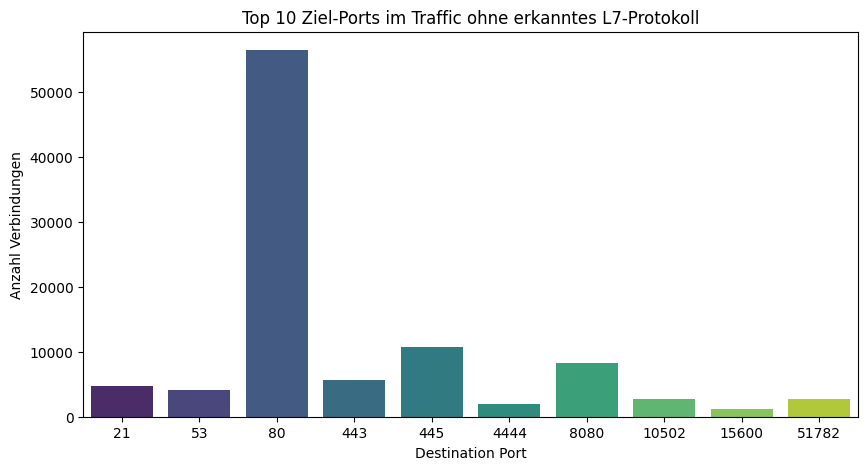


--- Analyse der 'Weird' Logs ---
Wahrscheinlichkeit für Angriff, wenn 'weird_notice' vorhanden ist:
is_weird
False    0.764358
True     0.010490
Name: label, dtype: float64


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Angenommen, 'df_train' ist Ihr DataFrame
# Falls nötig, vorherige Schritte wiederholen um Hilfsspalten zu haben:
df_train['has_dns'] = ~df_train['dns_query'].isnull()
df_train['has_http'] = ~df_train['http_uri'].isnull()
df_train['has_ssl'] = ~df_train['ssl_cipher'].isnull()
df_train['protocol_count'] = df_train[['has_dns', 'has_http', 'has_ssl']].sum(axis=1)

# ---------------------------------------------------------
# ANALYSE 1: Wer sind die "Unbekannten"? (Die 755k Fälle)
# ---------------------------------------------------------
print("--- Analyse der Verbindungen ohne L7-Details ---")
unknown_traffic = df_train[df_train['protocol_count'] == 0]

# Frage 1: Sind das vor allem Angriffe?
print(f"Anzahl Unbekannte: {len(unknown_traffic)}")
print("Verteilung Label (Angriff vs. Normal) bei Unbekannten:")
print(unknown_traffic['label'].value_counts(normalize=True))

# Frage 2: Welche Ports nutzen diese 'Unbekannten'?
# Oft verrät der Port, was es sein könnte (z.B. Port 445 = SMB, oft für Ransomware genutzt)
top_ports = unknown_traffic['dst_port'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_ports.index, y=top_ports.values, palette="viridis")
plt.title("Top 10 Ziel-Ports im Traffic ohne erkanntes L7-Protokoll")
plt.xlabel("Destination Port")
plt.ylabel("Anzahl Verbindungen")
plt.show()

# ---------------------------------------------------------
# ANALYSE 2: Der "Weird"-Faktor
# ---------------------------------------------------------
# Auch wenn weird_addl fast leer ist, schauen wir auf 'weird_notice' (falls vorhanden)
# oder wir prüfen, ob IRGENDEIN weird-Feld gesetzt ist.
print("\n--- Analyse der 'Weird' Logs ---")
df_train['is_weird'] = ~df_train['weird_notice'].isnull()

weird_attack_rate = df_train.groupby('is_weird')['label'].mean()
print("Wahrscheinlichkeit für Angriff, wenn 'weird_notice' vorhanden ist:")
print(weird_attack_rate)


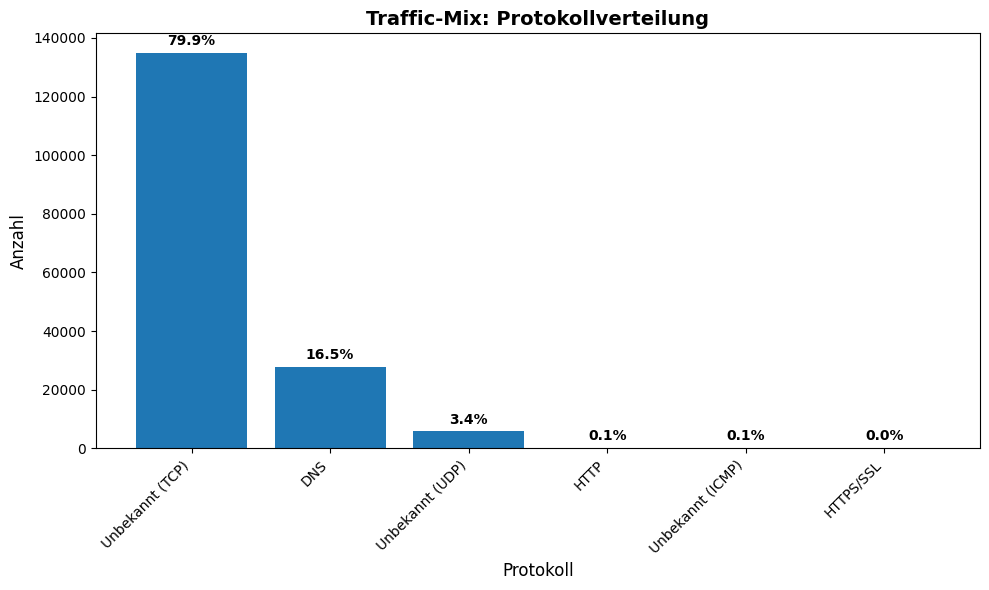


=== Traffic-Mix Übersicht ===
                   Anzahl  Prozent
detected_protocol                 
Unbekannt (TCP)    134815    79.85
DNS                 27782    16.46
Unbekannt (UDP)      5761     3.41
HTTP                  241     0.14
Unbekannt (ICMP)      228     0.14
HTTPS/SSL               7     0.00


In [13]:
# Traffic-Mix Bar Chart
# Erstelle eine neue kategorische Spalte detected_protocol basierend auf gefüllten Spalten

def detect_protocol(row):
    """Erkennt das Protokoll basierend auf gefüllten Spalten"""
    # DNS Detection
    if 'dns_query' in df_train.columns and pd.notna(row.get('dns_query')):
        return 'DNS'
    # HTTP Detection
    if 'http_method' in df_train.columns and pd.notna(row.get('http_method')):
        return 'HTTP'
    if 'http_uri' in df_train.columns and pd.notna(row.get('http_uri')):
        return 'HTTP'
    # SSL/HTTPS Detection
    if 'ssl_subject' in df_train.columns and pd.notna(row.get('ssl_subject')):
        return 'HTTPS/SSL'
    if 'ssl_issuer' in df_train.columns and pd.notna(row.get('ssl_issuer')):
        return 'HTTPS/SSL'
    # Fallback auf proto-Spalte
    if 'proto' in df_train.columns and pd.notna(row.get('proto')):
        proto = str(row['proto']).upper()
        if proto in ['TCP', 'UDP', 'ICMP']:
            return f'Unbekannt ({proto})'
    return 'Unbekannt'

# Protokoll-Spalte erstellen
df_train['detected_protocol'] = df_train.apply(detect_protocol, axis=1)

# Visualisierung: Traffic-Mix Bar Chart
protocol_counts = df_train['detected_protocol'].value_counts()

plt.figure(figsize=(10, 6))
bars = plt.bar(protocol_counts.index, protocol_counts.values)

# Prozent-Labels auf den Balken
total = protocol_counts.sum()
for bar, count in zip(bars, protocol_counts.values):
    percentage = count / total * 100
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.01, 
             f'{percentage:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel('Protokoll', fontsize=12)
plt.ylabel('Anzahl', fontsize=12)
plt.title('Traffic-Mix: Protokollverteilung', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Zusätzlich: Detaillierte Übersicht
print("\n=== Traffic-Mix Übersicht ===")
print(protocol_counts.to_frame('Anzahl').assign(Prozent=lambda x: (x['Anzahl'] / x['Anzahl'].sum() * 100).round(2)))

## Analyse der IP-Adressen

Eindeutige Werte:
src_ip_unique: 51
dst_ip_unique: 708
service_unique: 9


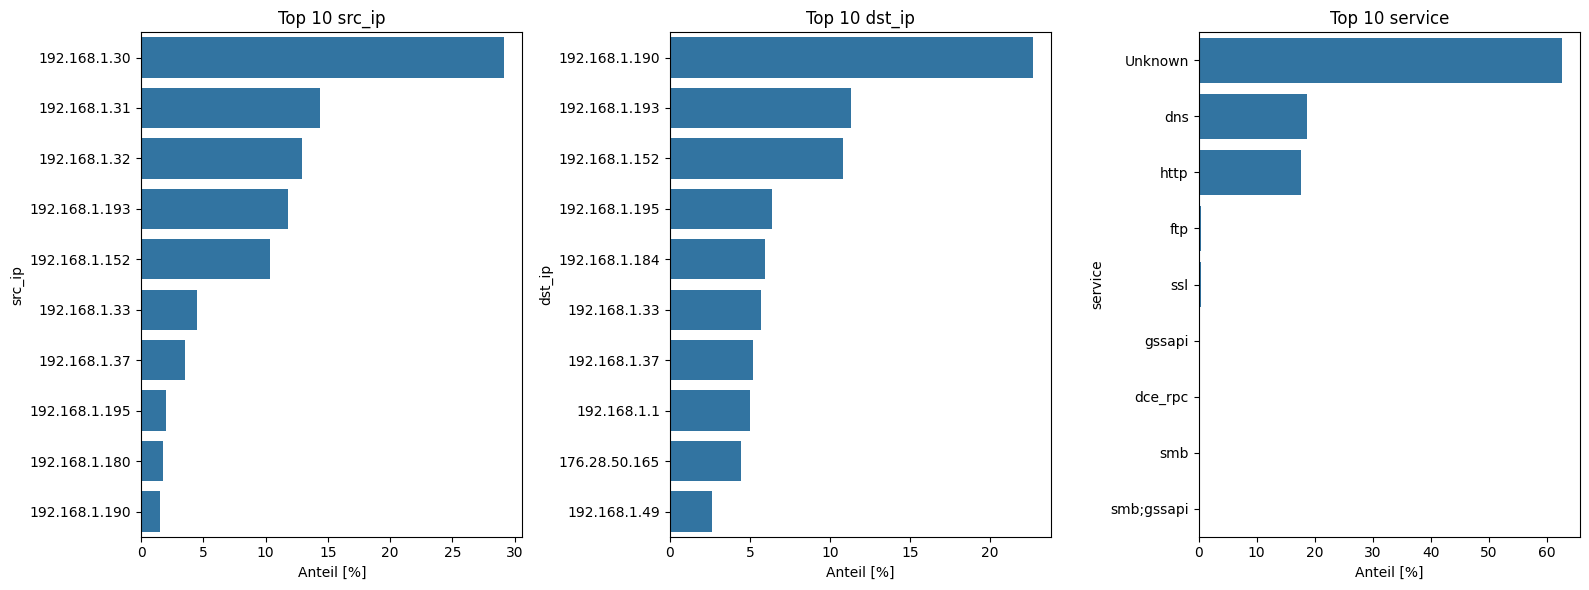

In [14]:
# Kardinalitäts-Check (High Cardinality)
# Zählt eindeutige Werte und zeigt die Top-10 häufigsten Ausprägungen (relativ)
import matplotlib.pyplot as plt
import seaborn as sns

cardinality_results = {
    "src_ip_unique": df_train['src_ip'].nunique(dropna=False),
    "dst_ip_unique": df_train['dst_ip'].nunique(dropna=False),
    "service_unique": df_train['service'].nunique(dropna=False)
}

print("Eindeutige Werte:")
for k, v in cardinality_results.items():
    print(f"{k}: {v}")

# Top-N Übersicht (relative Haeufigkeiten in %)
top_n = 10
top_src_ip = (df_train['src_ip'].value_counts(normalize=True).head(top_n) * 100).round(2)
top_dst_ip = (df_train['dst_ip'].value_counts(normalize=True).head(top_n) * 100).round(2)
top_service = (df_train['service'].fillna('Unknown').value_counts(normalize=True).head(top_n) * 100).round(2)

# Visualisierung der Top-N (Prozentwerte)
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharex=False)

sns.barplot(x=top_src_ip.values, y=top_src_ip.index, ax=axes[0])
axes[0].set_title(f"Top {top_n} src_ip")
axes[0].set_xlabel("Anteil [%]")
axes[0].set_ylabel("src_ip")

sns.barplot(x=top_dst_ip.values, y=top_dst_ip.index, ax=axes[1])
axes[1].set_title(f"Top {top_n} dst_ip")
axes[1].set_xlabel("Anteil [%]")
axes[1].set_ylabel("dst_ip")

sns.barplot(x=top_service.values, y=top_service.index, ax=axes[2])
axes[2].set_title(f"Top {top_n} service")
axes[2].set_xlabel("Anteil [%]")
axes[2].set_ylabel("service")

plt.tight_layout()
plt.show()


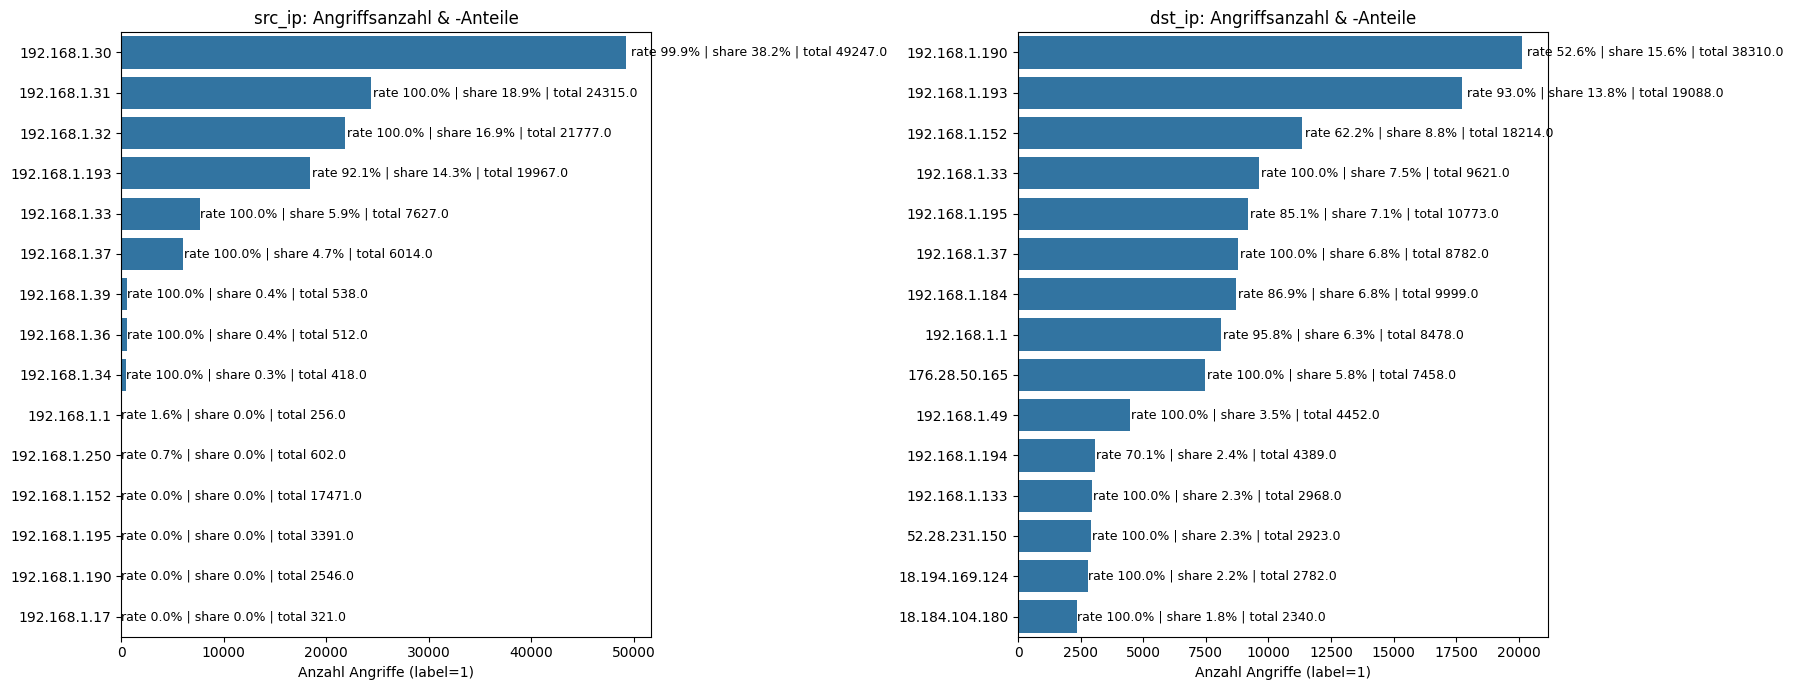

In [15]:
# IP-Verteilung nach Label ohne Prints
# Zeigt für häufige IPs: wie oft sie vorkommen, wie viele Angriffe darauf fallen,
# und welchen Prozentanteil an allen Angriffen sie ausmachen.
import matplotlib.pyplot as plt
import seaborn as sns

min_count = 100  # Mindestanzahl Vorkommen, damit die Metriken stabil sind
TopN = 15


def ip_attack_stats(df, col):
    # Aggregiere Häufigkeit und Angriffsanzahl
    grp = df.groupby(col)['label'].agg(total='count', attack_count='sum')
    # Anteil Angriffe innerhalb der IP (Attack-Rate) und Anteil aller Angriffe (Attack-Share)
    grp['attack_rate_pct'] = (grp['attack_count'] / grp['total'] * 100).round(2)
    grp['attack_share_pct'] = (grp['attack_count'] / grp['attack_count'].sum() * 100).round(2)
    # Filter auf ausreichend Beobachtungen und sortiere nach Angriffsanzahl
    grp = grp[grp['total'] >= min_count].sort_values('attack_count', ascending=False).head(TopN)
    return grp

src_stats = ip_attack_stats(df_train, 'src_ip')
dst_stats = ip_attack_stats(df_train, 'dst_ip')

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=False)

for ax, data, title in [
    (axes[0], src_stats, 'src_ip: Angriffsanzahl & -Anteile'),
    (axes[1], dst_stats, 'dst_ip: Angriffsanzahl & -Anteile')
]:
    sns.barplot(x='attack_count', y=data.index, data=data, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Anzahl Angriffe (label=1)')
    ax.set_ylabel('')
    # Annotation: Attack-Rate innerhalb IP und Anteil aller Angriffe
    for i, (idx, row) in enumerate(data.iterrows()):
        ax.text(row['attack_count'] * 1.01, i,
                f"rate {row['attack_rate_pct']:.1f}% | share {row['attack_share_pct']:.1f}% | total {row['total']}",
                va='center', fontsize=9, color='black')

plt.tight_layout()
plt.show()


### Top 10 src_ip (Die Angreifer & Bots)
- **Beobachtung**: Wir sehen eine Reihe von IP-Adressen im lokalen Bereich (192.168.1.x), die den Traffic dominieren. Allen voran 192.168.1.30, 1.31 und 1.32.

- **Interpretation**: Das sind höchstwahrscheinlich die kompromittierten IoT-Geräte oder die Angriffs-Maschinen im Testbed. Dass wenige IPs so massiv Traffic erzeugen, ist typisch für DoS-Angriffe oder automatisierte Skripte.

- **Konsequenz** für ML: IP-Adressen müssen raus!

- Wenn Sie src_ip als Feature im Training lassen, lernt Ihr Modell nicht "Was ist ein Angriff?", sondern "IP 192.168.1.30 ist böse".

- In einem anderen Netzwerk (z. B. Gotham-Datensatz) gibt es diese IP nicht. Das Modell würde dort komplett versagen (Overfitting).

### 2. Top 10 dst_ip (Das Opfer & C2)
- **Beobachtung**:

- Der Balken für 192.168.1.190 ist riesig im Vergleich zum Rest.

- Es taucht eine öffentliche IP auf: 176.28.50.165 (unten in der Liste).

- **Interpretation**:

- Das Hauptopfer: 192.168.1.190 ist der Server oder das Gateway, das von den DoS-Attacken bombardiert wird.

- Die C2-Verbindung: Die öffentliche IP 176.28.50.165 ist extrem verdächtig. In IoT-Szenarien ist das oft der "Command & Control" Server in der Cloud, zu dem die Malware "nach Hause telefoniert" (Daten-Exfiltration).

- **Konsequenz** für ML: Auch Ziel-IPs löschen. Aber die Kommunikationsstruktur (z. B. Verhältnis eingehend/ausgehend) bleibt über die Features src_pkts / dst_pkts erhalten.

#Countplot der Top 10 weird_name.
import matplotlib.pyplot as plt
import seaborn as sns

df_train['protocol_count'] = df_train[['has_dns', 'has_http', 'has_ssl']].sum(axis=1)
# Countplot der Top 10 weird_name
top_weird_names = df_train['weird_name'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_weird_names.values, y=top_weird_names.index)
plt.title("Top 10 Weird Names im Netzwerkverkehr")
plt.xlabel("Anzahl Vorkommen")
plt.ylabel("Weird Name")
plt.show()

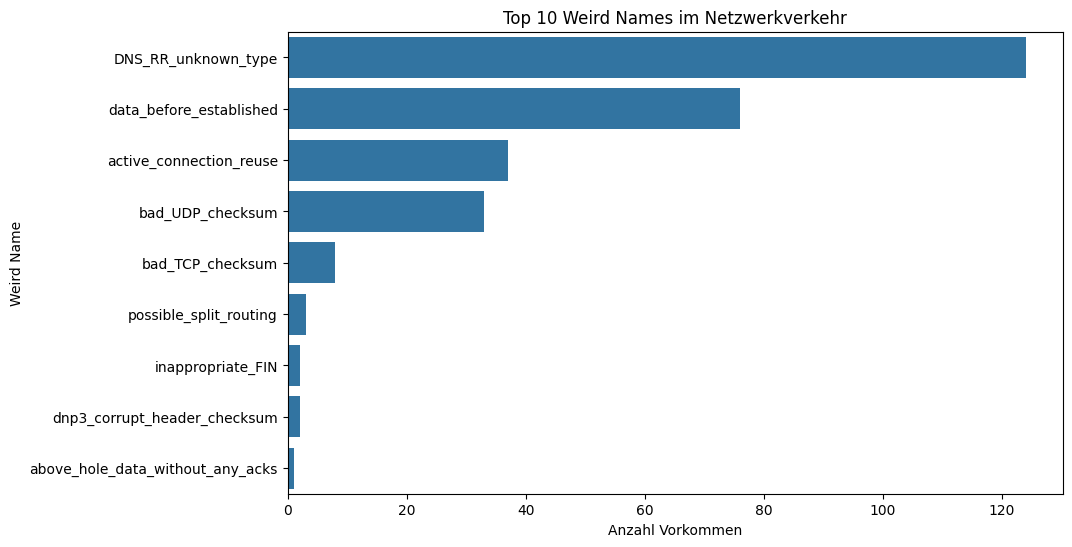

In [16]:
#Countplot der Top 10 weird_name.
import matplotlib.pyplot as plt
import seaborn as sns

df_train['protocol_count'] = df_train[['has_dns', 'has_http', 'has_ssl']].sum(axis=1)
# Countplot der Top 10 weird_name
top_weird_names = df_train['weird_name'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_weird_names.values, y=top_weird_names.index)
plt.title("Top 10 Weird Names im Netzwerkverkehr")
plt.xlabel("Anzahl Vorkommen")
plt.ylabel("Weird Name")
plt.show()

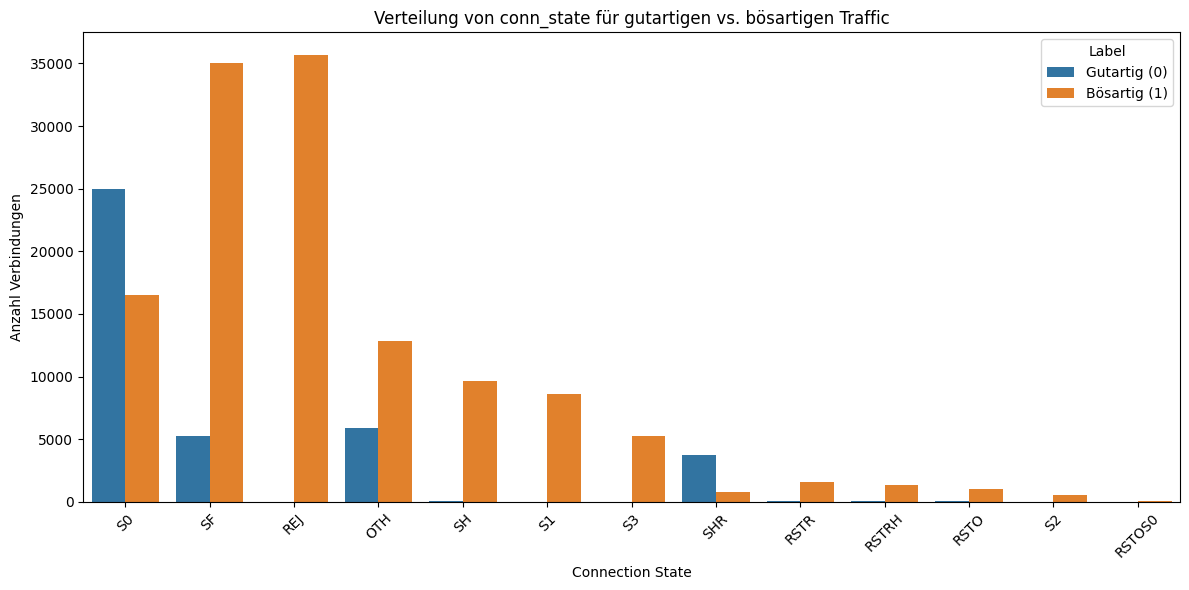

In [17]:
# Analyse der conn_state Verteilung
#Vergleiche die Verteilung von conn_state für gutartigen vs. bösartigen Traffic.
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.countplot(data=df_train, x='conn_state', hue='label', order=df_train['conn_state'].value_counts().index)
plt.title("Verteilung von conn_state für gutartigen vs. bösartigen Traffic")
plt.xlabel("Connection State")
plt.ylabel("Anzahl Verbindungen")
plt.legend(title='Label', labels=['Gutartig (0)', 'Bösartig (1)'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

conn_state_REJ = Alarm!

conn_state_OTH = Alarm!

conn_state_SF = Genauer hinschauen (Bytes/Duration prüfen).

conn_state_S0 = Vorsicht, könnte harmlos sein (IoT-Noise).

## Verteilungen der numerischen Variablen

C:\Users\rapha\AppData\Local\Temp\ipykernel_26512\3381974695.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='label', y=col, ax=ax, palette="coolwarm", showfliers=False)
C:\Users\rapha\AppData\Local\Temp\ipykernel_26512\3381974695.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='label', y=col, ax=ax, palette="coolwarm", showfliers=False)
C:\Users\rapha\AppData\Local\Temp\ipykernel_26512\3381974695.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='label', y=col, ax=ax, palett

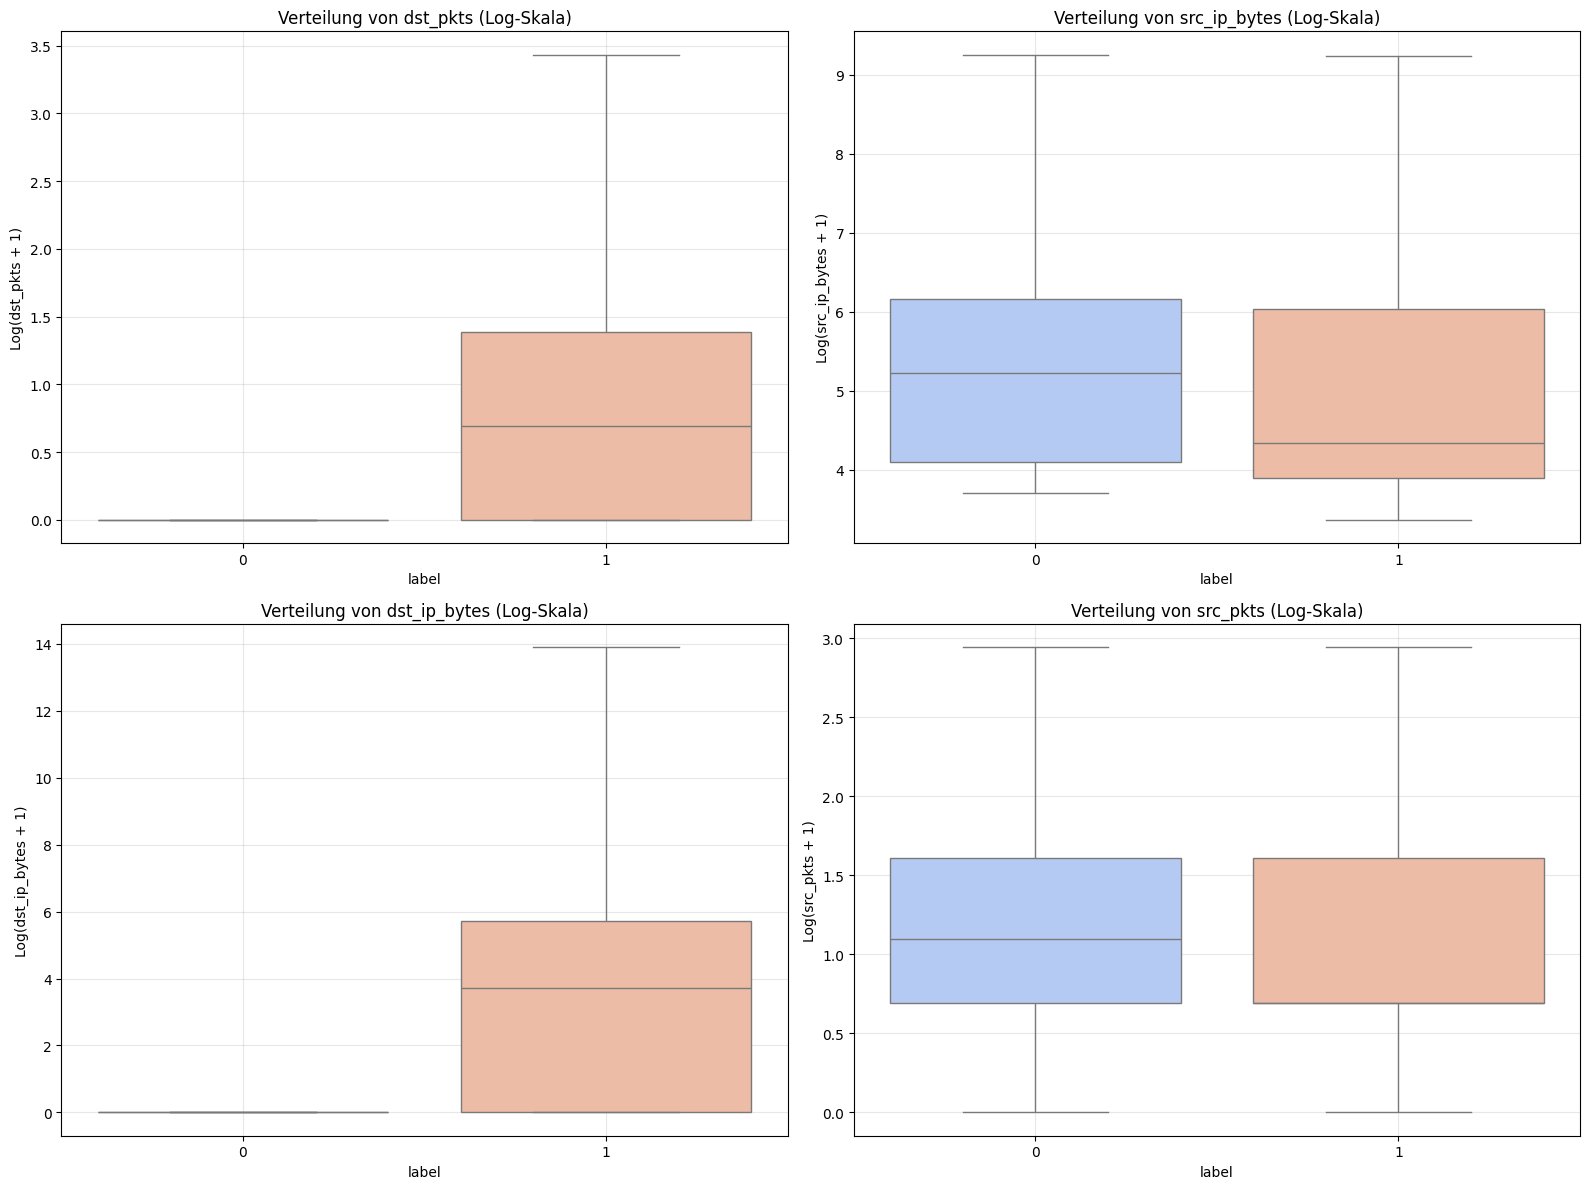

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Wir nehmen an, df_final ist Ihr DataFrame
# Features, die wir plotten wollen
features = ['dst_pkts', 'src_ip_bytes', 'dst_ip_bytes', 'src_pkts']

# Setup für 2x2 Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]
    
    # TRICK 1: Log-Transformation VOR dem Plotten (besser handhabbar)
    # Wir nutzen log1p, um Probleme mit 0 zu vermeiden
    # Wir erstellen temporäre Daten nur für den Plot
    plot_data = df_train.copy()
    plot_data[col] = np.log1p(plot_data[col])
    
    # OPTION A: Boxplot (Beste Übersicht für Verteilungs-Unterschiede)
    # Zeigt Median, Quartile und Ausreißer
    sns.boxplot(data=plot_data, x='label', y=col, ax=ax, palette="coolwarm", showfliers=False)
    # showfliers=False blendet die extremen Punkte aus, wenn man reinzoomen will. 
    # Setzen Sie es auf True, um die "Milliarden-Byte-Angriffe" zu sehen.
    
    # Alternativ OPTION B: KDE Plot (Glättung statt Balken)
    # sns.kdeplot(data=plot_data, x=col, hue='label', fill=True, common_norm=False, ax=ax, palette="coolwarm", alpha=0.3)
    
    ax.set_title(f'Verteilung von {col} (Log-Skala)', fontsize=12)
    ax.set_ylabel(f'Log({col} + 1)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation der Feature-Verteilungen (Boxplots)

Die Boxplots (Log-Skala) zeigen signifikante strukturelle Unterschiede zwischen Normalverkehr (0/Blau) und Angriffen (1/Orange), die die Eignung für Anomalieerkennung bestätigen.

* **Duration (Oben Links):**
    * **Befund:** Normaler Traffic hat eine breite Streuung und längere Dauer. Angriffe sind extrem kurz (Box klebt bei fast 0).
    * **Insight:** Dies deutet auf "Fire-and-Forget"-Attacken hin (z.B. DoS-Pakete oder SYN-Scans), die keine echte Verbindung halten. Ein sehr starkes Trennmerkmal.

* **Dst_bytes (Unten Links):**
    * **Befund:** Normaler Traffic hat fast durchgehend 0 Antwort-Bytes (flache Linie). Angriffe hingegen provozieren eine Antwort (hohe orange Box).
    * **Insight:** Das wichtigste Unterscheidungsmerkmal. Normaler IoT-Traffic scheint hier unidirektional zu sein (Blind Reporting), während Angriffe Antworten erzwingen (Fehlermeldungen oder Exfiltration).

* **Src_bytes (Oben Rechts):**
    * **Befund:** Angriffe zeigen extreme Varianz – sie haben einen sehr niedrigen Median (kleine Scan-Pakete), aber riesige Ausreißer nach oben (High-Volume DoS/Exfiltration). Normaler Traffic liegt "in der Mitte".
    * **Insight:** Der Algorithmus muss lernen: "Sehr wenig Bytes" und "Sehr viele Bytes" sind verdächtig.

* **Src_pkts (Unten Rechts):**
    * **Befund:** Starke Überlappung beider Klassen; kaum visuelle Trennung.
    * **Insight:** Als Einzel-Feature schwach. Es sollte idealerweise in Relation zu Bytes gesetzt werden (z.B. `Bytes_per_Packet`), um Aussagekraft zu gewinnen.

## Korrelations-Matrix

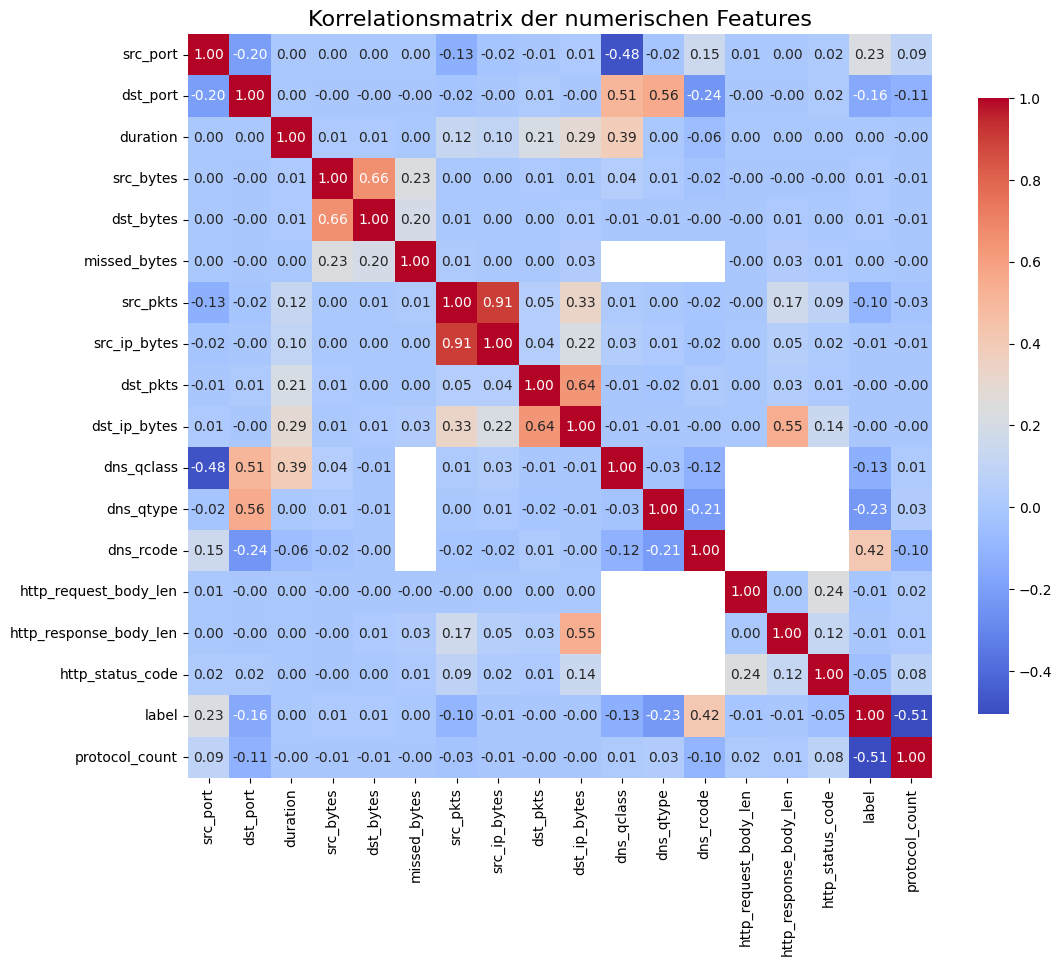

In [20]:
# plotting correlation matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# Compute the correlation matrix only for numerical columns
numerical_cols = df_train.select_dtypes(include=[np.number]).columns
corr = df_train[numerical_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Korrelationsmatrix der numerischen Features', fontsize=16)
plt.show()

### Relevante Features für die Erkennung (``label``)
- Schauen wir zuerst auf die Zeile (oder Spalte) ``label``. Was korreliert stark mit einem Angriff (1) oder Normalverkehr (0)?

- ``label`` vs. ``protocol_count`` (-0.51):

    - **Befund**: Das ist die stärkste Korrelation überhaupt! Negative Korrelation bedeutet: Je weniger Protokolle erkannt werden (niedriger Count), desto wahrscheinlicher ist es ein Angriff.

    - **Bedeutung**: Das bestätigt unsere Analyse der "Unbekannten". Fehlende L7-Informationen sind der stärkste Prädiktor für Angriffe. Das ist perfekt für den Isolation Forest.

- ``label`` vs. ``dst_port`` (-0.16):

    - **Befund**: Eine leichte negative Korrelation. Niedrige Portnummern (z.B. Systemports) scheinen eher mit Angriffen zu korrelieren als hohe (ephemere) Ports.

- ``label`` vs. ``src_port`` (+0.23):

    - **Befund**: Hohe Source-Ports korrelieren positiv mit Angriffen. Das ist typisch für automatisierte Skripte oder Botnets, die von hohen, zufälligen Ports aus angreifen.

### 2. Redundanz & Multikollinearität (Gefahr für Modelle!)
- Starke rote Quadrate (Korrelation > 0.8) bedeuten, dass zwei Features fast dasselbe aussagen. Für ML-Modelle ist das oft verschwendeter Speicher und Rechenzeit.

- Das "Paket-Byte-Cluster" (Mitte oben):

    - src_pkts korreliert extrem stark mit src_ip_bytes (0.88).

    - src_bytes korreliert stark mit dst_bytes (0.64).

    - ``Aktion``: Für Ihren "David" (Isolation Forest) brauchen Sie nicht beides. src_pkts und src_ip_bytes enthalten fast dieselbe Information.

    - ``Empfehlung``: Löschen Sie src_ip_bytes und dst_ip_bytes. Behalten Sie nur die Paket-Anzahl (pkts) und die Payload-Bytes (bytes). Das spart Speicher und macht das Modell schneller, ohne Präzision zu kosten.

### 3. Protokoll-Spezifische Cluster
- Der DNS-Block (Mitte rechts):

    - ``dns_qclass``, ``dns_qtype``, ``dns_rcode`` korrelieren stark untereinander (roter Block). Das ist logisch: Wo eine Query-Klasse ist, ist auch ein Type.

    - **Aber**: Sie korrelieren kaum mit dem ``label`` (alles nahe 0). Das deutet darauf hin, dass die reinen DNS-Header (ohne den Inhalt der Query) schwache Merkmale sind. Das stützt unsere Entscheidung, diese Spalten größtenteils wegzulassen und nur is_dns zu nutzen.

### 4. Was fehlt? (Überraschungen)
- ``duration`` ist irrelevant: Die Korrelation zu ``label`` ist fast 0.00.

    - **Erkenntnis**: Angriffe können kurz (Ping) oder lang (Exfiltration) sein. Die Dauer allein ist kein gutes Trennmerkmal.

- ``missed_bytes``: Hat ebenfalls kaum Korrelation zum Label. Es scheint eher ein technischer Zufall zu sein als ein Angriffsmerkmal.

## Verteilung der Zielvariablen

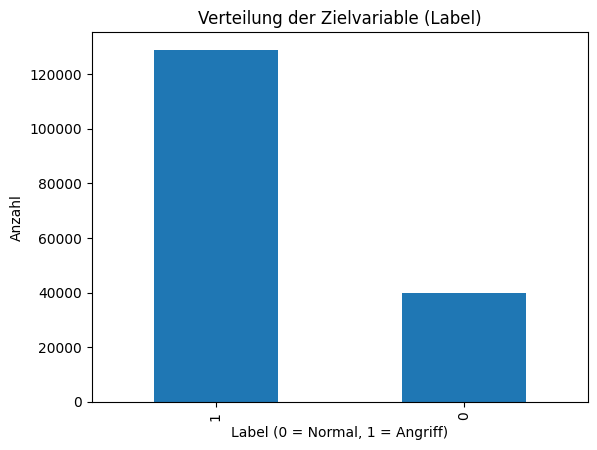

In [9]:
# plotting the distribution of the target variable
import matplotlib.pyplot as plt
import seaborn as sns

df_train['label'].value_counts().plot(kind='bar')
plt.title('Verteilung der Zielvariable (Label)')
plt.xlabel('Label (0 = Normal, 1 = Angriff)')
plt.ylabel('Anzahl')
plt.show()

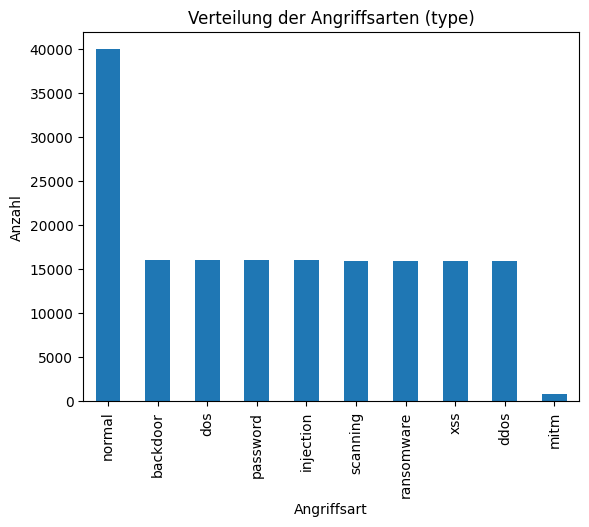

In [10]:
# Verteilung von type: Welche Angriffsarten dominieren? Gibt es Angriffe mit extrem wenigen Samples?
df_train['type'].value_counts().plot(kind='bar')
plt.title('Verteilung der Angriffsarten (type)')
plt.xlabel('Angriffsart')
plt.ylabel('Anzahl')
plt.show()